In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns

In [2]:
df = pd.read_csv('data/messibetis.csv')

In [3]:
df['x'] = df['x'] * 1.2
df['endX'] = df['endX'] * 1.2
df['y'] = df['y'] * .8
df['endY'] = df['endY'] * .8

Text(0.5, 1.0, 'Lionel Messi pass map vs Real Betis')

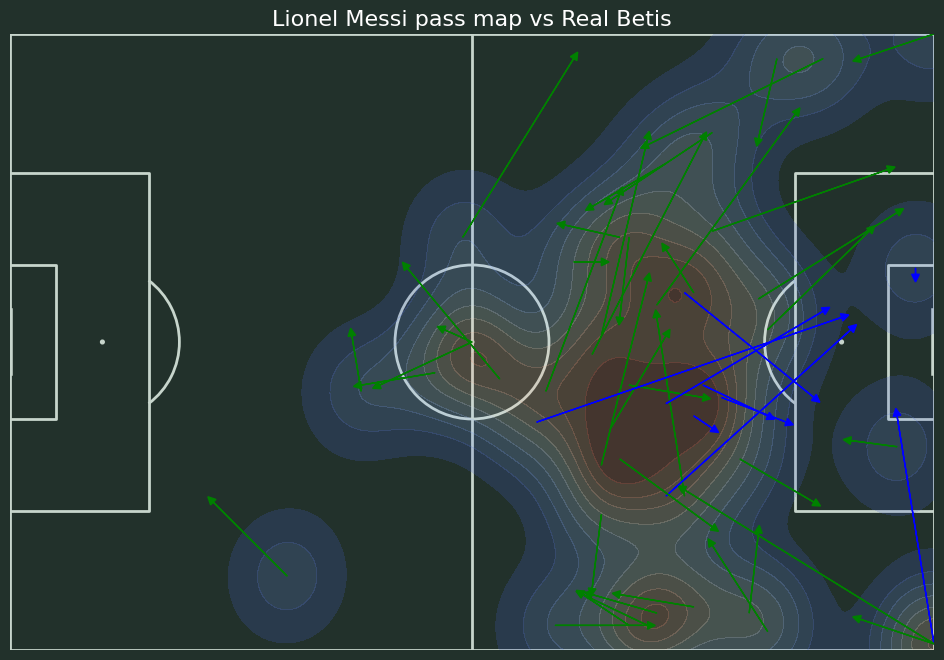

In [5]:
fig, ax= plt.subplots(figsize=(13.5, 8))
fig.set_facecolor('#22312b')
ax.patch.set_facecolor('#22312b')
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
pitch.draw(figsize=(13, 8), constrained_layout=True, tight_layout=False, ax=ax)
plt.gca().invert_yaxis()

#Create the heatmap
kde = sns.kdeplot(x=df['x'], y=df['y'], fill=True, shade_lowest=False, alpha=.2, n_levels=10, cmap='coolwarm', bw_adjust=.5)

for x in range(len(df['x'])):
    if df['outcome'][x] == 'Successful':
        #plt.plot((df['x'][x], df['endX'][x]), (df['y'][x], df['endY'][x]), color='green')
        #plt.scatter(df['x'][x], df['y'][x], color='green')
        plt.arrow(df['x'][x], df['y'][x], df['endX'][x]-df['x'][x], df['endY'][x]-df['y'][x], head_width=1, head_length=1, color='green')
    else:
        #plt.plot((df['x'][x], df['endX'][x]), (df['y'][x], df['endY'][x]), color='blue')
        plt.arrow(df['x'][x], df['y'][x], df['endX'][x]-df['x'][x], df['endY'][x]-df['y'][x], head_width=1, head_length=1, color='blue')
        #plt.scatter(df['x'][x], df['y'][x], color='blue')

plt.xlim(0, 120)
plt.ylim(0, 80)
plt.title("Lionel Messi pass map vs Real Betis", color='white', fontsize=16)